In [2]:
from tqdm import tqdm
from pathlib import Path

import sys
import matplotlib.pyplot as plt

path = Path.cwd()
while not (path / "computer_vision").exists():
    path = path.parent

sys.path.append(str(path))

datasets_path = "/home/otokonokage/Documents/github/dataset/computer_vision/"

# **Face Detection**

In [3]:
from computer_vision.dataset import prepare_facedetection

import torch
size = 224
box_format = "xywh"
train, validation, weights, num_classes, categories, _, _ = prepare_facedetection(datasets_path, size=size, box_format="xywh")

100%|██████████| 6573/6573 [00:52<00:00, 126.00it/s]


**YOLOV3 abilities on Face Detection Dataset**

In [41]:
S = [size // 32, size // 16, size // 8]
num_bboxes_prior_per_scale = 5

from computer_vision.yolo.yolov3.yolo_tools import generate_bboxes_prior

bboxes_prior = generate_bboxes_prior(train, num_bboxes_prior_per_scale, box_format)
bboxes_prior = bboxes_prior.reshape((3 * num_bboxes_prior_per_scale, 2))

100%|██████████| 26266/26266 [00:00<00:00, 1329258.18it/s]


In [42]:
num_images = 0
num_bboxes = 0
total_bboxes = 0

In [43]:
from computer_vision.yolo.yolov3.yolo_tools import intersection_over_union_bboxes_prior

for (_, bboxes), (_, labels) in tqdm(zip(train["bboxes"].items(), train["labels"].items()), total=len(train["bboxes"]), leave=True):
    num_elements = 6 if num_classes > 1 else 5
    grid_label = [torch.zeros((num_bboxes_prior_per_scale, s, s, num_elements), dtype=torch.float32) for s in S]

    image_boolean = True
    if labels != []:
        for bbox, label in zip(bboxes, labels):
            total_bboxes += 1
            if box_format == "xyxy":
                x, y, x2, y2 = bbox
                w = x2 - x
                h = y2 - y
            elif box_format == "xywh":
                x, y, w, h = bbox
            elif box_format == "xcycwh":
                xc, yc, w, h = bbox
                x = xc - (w / 2)
                y = yc - (h / 2)

            if x > 1.:
                x = 0.99
            elif y > 1.:
                y = 0.99

            has_bboxes_prior = [False] * 3

            ious_prior = intersection_over_union_bboxes_prior(torch.tensor(bbox[2:4]), bboxes_prior)

            ious_prior_indices = ious_prior.argsort(descending=True, dim=0)

            for prior_indice in ious_prior_indices:
                scale_indice = prior_indice // num_bboxes_prior_per_scale

                prior_indice_compared_to_scale = prior_indice % num_bboxes_prior_per_scale

                s = S[scale_indice]
                i, j = int(s * y), int(s * x)

                cell_taken = grid_label[scale_indice][prior_indice_compared_to_scale, i, j, 0]
                if not cell_taken and not has_bboxes_prior[scale_indice]:
                    grid_label[scale_indice][prior_indice_compared_to_scale, i, j, 0] = 1.

                    x_cell, y_cell = s * x - j, s * y - i
                    width_cell, height_cell = (w * s, h * s)

                    box_coordinates = torch.tensor([x_cell, y_cell, width_cell, height_cell])
                    grid_label[scale_indice][prior_indice_compared_to_scale, i, j, 1:5] = box_coordinates

                    if num_classes > 1:
                        grid_label[scale_indice][prior_indice_compared_to_scale, i, j, 5] = int(label)
                    has_bboxes_prior[scale_indice] = True
            
            if not (has_bboxes_prior[0] or has_bboxes_prior[1] or has_bboxes_prior[2]):
                num_bboxes += 1
                if image_boolean:
                    image_boolean = False
                    num_images += 1

100%|██████████| 26266/26266 [00:51<00:00, 512.59it/s] 


In [44]:
print(num_bboxes)
print(total_bboxes)

1652
200967


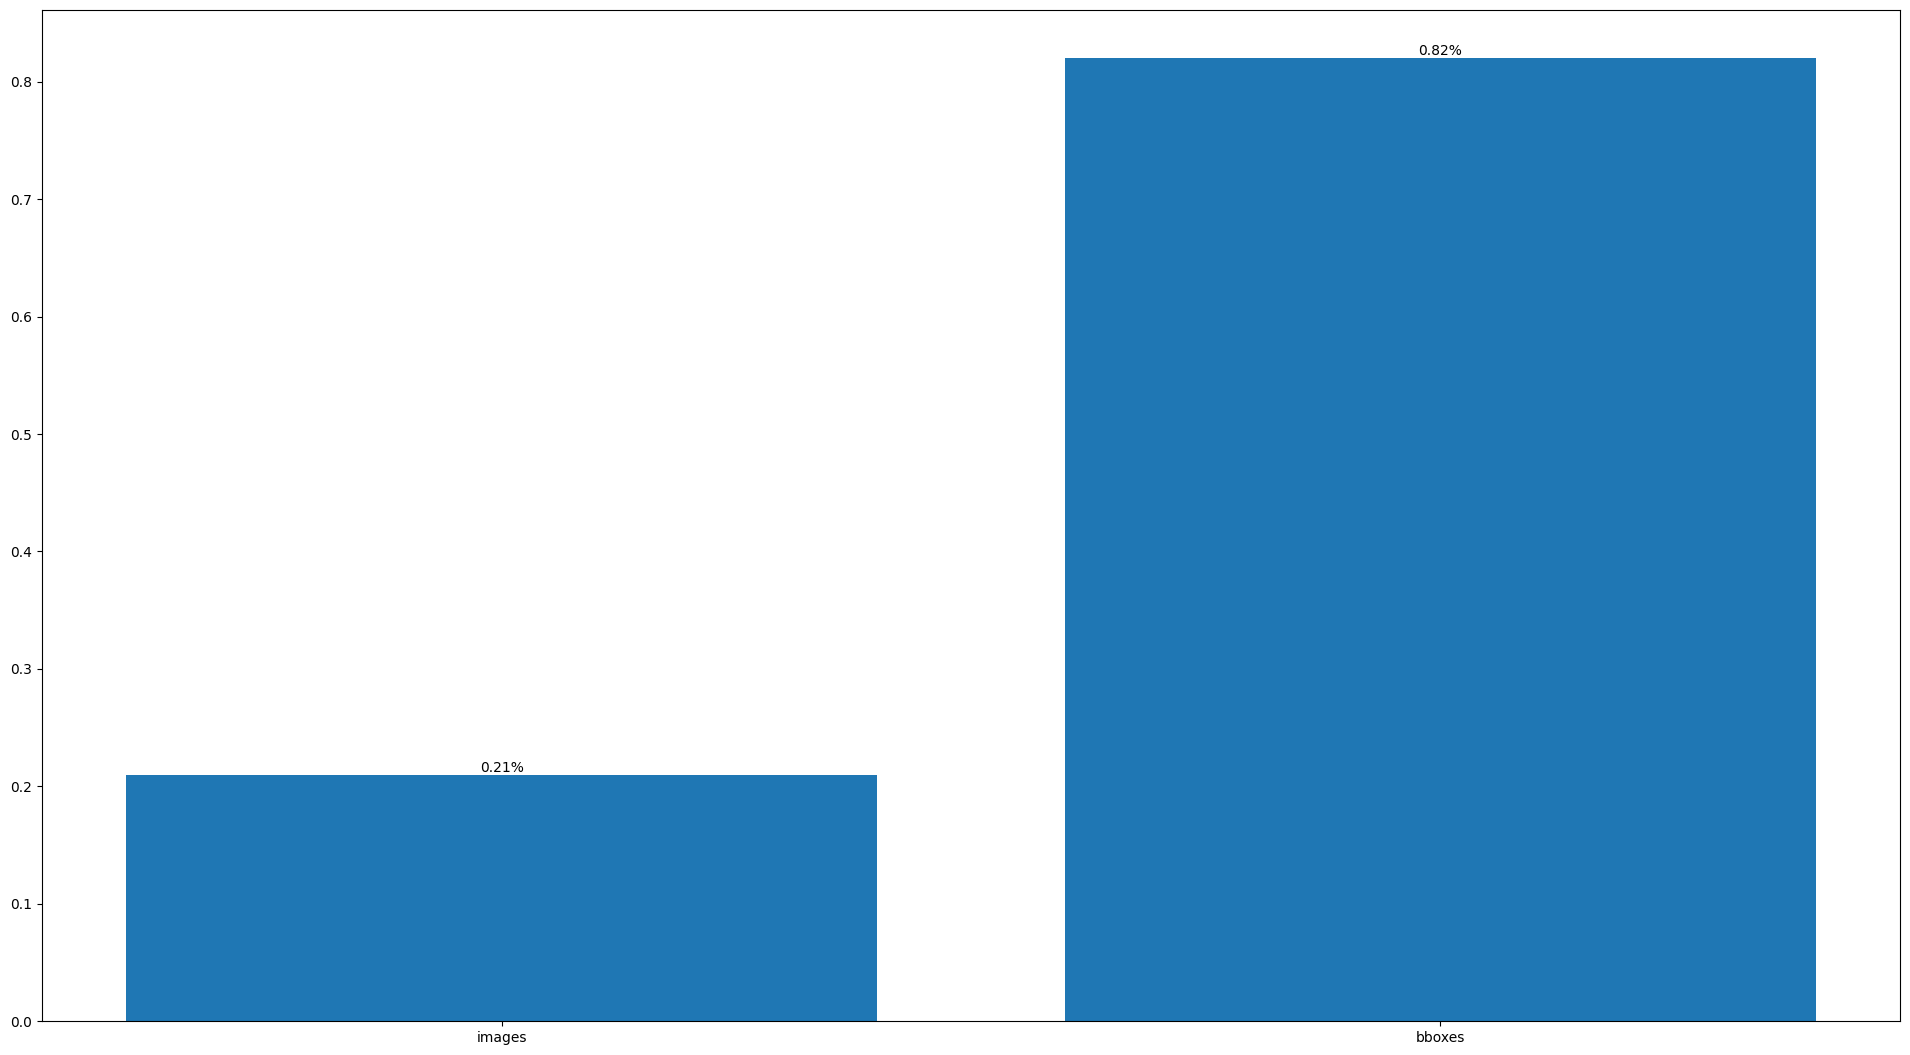

In [46]:
plt.figure(figsize=(19.2, 10.8))

percs = [round(num_images / len(train["images"]), 4) * 100, round(num_bboxes / total_bboxes, 4) * 100]
barplot = plt.bar(range(2), percs)
plt.bar_label(barplot, [f"{round(p, 3)}%" for p in percs])
plt.xticks(range(2), ["images", "bboxes"])
plt.suptitle("")
plt.tight_layout()
plt.show()